Prophet : 메타에서 만든 시계열 모델

데이터 1~8번까지 사용하고
(a) 표처럼 x 입력했을때 y 나오도록 코드 짜

In [13]:
# 상추 데이터 (1~8일)
data = [12, 10, 8, 15, 16, 15, 14, 16]

# X, y 출력
for i in range(len(data) - 3):
    X = data[i:i+3]      # 이전 3일
    y = data[i+3]        # 다음 날
    print(f"X: {X} → y: {y}")


X: [12, 10, 8] → y: 15
X: [10, 8, 15] → y: 16
X: [8, 15, 16] → y: 15
X: [15, 16, 15] → y: 14
X: [16, 15, 14] → y: 16


In [14]:
data = [12, 10, 8, 15, 16, 15, 14, 16]

window = 4   # 과거 3개를 보고 (X)
horizon = 2  # 미래 1개를 맞춘다 (y)

X = [] # 문제지 (Input)
y = [] # 정답지 (Target)


for i in range(len(data) - window):

# 문제 만들기 (i부터 window개수 만큼 자르기)
    input_seq = data[i : i + window]

# 정답 만들기 (window 바로 다음 숫자 가져오기)
    target = data[i + window: i + window + horizon]

    print(f"[{i}번째] 문제: {input_seq} -> 정답: {target}")

    X.append(input_seq)
    y.append(target)

[0번째] 문제: [12, 10, 8, 15] -> 정답: [16, 15]
[1번째] 문제: [10, 8, 15, 16] -> 정답: [15, 14]
[2번째] 문제: [8, 15, 16, 15] -> 정답: [14, 16]
[3번째] 문제: [15, 16, 15, 14] -> 정답: [16]


In [15]:
# 1. 시계열 데이터를 준비
import numpy as np

# 시계열 (슬라이드에 있던 값)
series = np.array([12, 10, 8, 15, 16, 15, 14, 16, 19, 20, 23, 22])

# 2. 원도우와 수평선 계수를 이용해 x,y 샘플 만들기
def make_dataset(series, window_size=3, horizon=1):
    X = []  # 입력 패턴들 (x)
    y = []  # 타깃값들   (y)

    # i에서 시작해 window_size개를 x, 그 뒤 horizon번째 값을 y로 사용
    for i in range(len(series) - window_size - horizon + 1):
        x_i = series[i : i + window_size]                 # 예: [12, 10, 8]
        y_i = series[i + window_size + horizon - 1]       # 예: 15
        X.append(x_i)
        y.append(y_i)

    return np.array(X), np.array(y)

X, y = make_dataset(series, window_size=3, horizon=1)

for i in range(9):
    print(f"데이터 {i+1}번째 샘플")
    print("X :", X[i])
    print("y :", y[i])
    print("==========")

데이터 1번째 샘플
X : [12 10  8]
y : 15
데이터 2번째 샘플
X : [10  8 15]
y : 16
데이터 3번째 샘플
X : [ 8 15 16]
y : 15
데이터 4번째 샘플
X : [15 16 15]
y : 14
데이터 5번째 샘플
X : [16 15 14]
y : 16
데이터 6번째 샘플
X : [15 14 16]
y : 19
데이터 7번째 샘플
X : [14 16 19]
y : 20
데이터 8번째 샘플
X : [16 19 20]
y : 23
데이터 9번째 샘플
X : [19 20 23]
y : 22


In [16]:
# 시계열 데이터 (예: 상추 1~8일 데이터)
data = [12, 10, 8, 15, 16, 15, 14, 16]

# 윈도우 크기(w)와 수평선 계수(h)
w = 3   # 이전 3일
h = 1   # 1일 뒤 예측

# X, y 샘플 생성
for i in range(len(data) - w - h + 1):
    X = data[i:i+w]          # i번째부터 w개
    y = data[i + w + h - 1]  # w일 뒤 + h offset
    print(f"X: {X} → y: {y}")


X: [12, 10, 8] → y: 15
X: [10, 8, 15] → y: 16
X: [8, 15, 16] → y: 15
X: [15, 16, 15] → y: 14
X: [16, 15, 14] → y: 16


In [17]:
# 강사님 코드
import numpy as np

x = [12, 10, 8, 15, 16, 15, 14, 16]

w=3
h=1

for i in range(len(x)-(w+h)+1):
  print(i)

0
1
2
3
4


In [18]:
###실습###

In [19]:
import tensorflow as tf

tf.keras.utils.set_random_seed(42)  # 난수(seed) 고정해서 같은 코드 + 같은 데이터 -> 항상 같은 결과 나오도록 설정
tf.config.experimental.enable_op_determinism()  # 연산 결과를 최대한 '완전 결정적'으로 만들겠다는 설정
# ㄴ> 가능한 연산들을 항상 같은 순서, 같은 방식으로 실행해서 랜덤 + 하드웨어 영향까지 줄여 완전히 같은 결과 얻으려고 시도

In [20]:
from tensorflow.keras.datasets import imdb  # Keras에서 제공하는 IMBD 영화 리뷰 감성분석용 데이터셋 불러오기
# imdb 데이터 -> 입력: 영화 리뷰, 타깃 : 0(부정리뷰), 1(긍정 리뷰)

(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=200)  # new_words : 자주 나오는 단어 상위 500개만 사용하고, 나머지 단어는 전부 OOV(unknown)으로 처리
#

In [21]:
train_input.shape, test_input.shape

((25000,), (25000,))

In [22]:
train_target.shape, test_target.shape

((25000,), (25000,))

In [23]:
len(train_input[0])

218

In [24]:
len(train_input[1])

189

In [25]:
train_input[1][:10]

[1, 194, 2, 194, 2, 78, 2, 5, 6, 2]

In [26]:
train_target[:10]

array([1, 0, 0, 1, 0, 0, 1, 0, 1, 0])

In [27]:
print(train_input[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 2, 2, 66, 2, 4, 173, 36, 2, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 2, 2, 5, 150, 4, 172, 112, 167, 2, 2, 2, 39, 4, 172, 2, 2, 17, 2, 38, 13, 2, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 2, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 2, 12, 8, 2, 8, 106, 5, 4, 2, 2, 16, 2, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 2, 28, 77, 52, 5, 14, 2, 16, 82, 2, 8, 4, 107, 117, 2, 15, 2, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 2, 26, 2, 2, 46, 7, 4, 2, 2, 13, 104, 88, 4, 2, 15, 2, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 2, 22, 21, 134, 2, 26, 2, 5, 144, 30, 2, 18, 51, 36, 28, 2, 92, 25, 104, 4, 2, 65, 16, 38, 2, 88, 12, 16, 2, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


In [28]:
from sklearn.model_selection import train_test_split

train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

In [29]:
train_input.shape, train_target.shape, val_input.shape, val_target.shape

((20000,), (20000,), (5000,), (5000,))

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow import keras
from sklearn.model_selection import train_test_split

In [31]:
lengths = np.array([len(x) for x in train_input])

In [32]:
np.mean(lengths), np.median(lengths)

(np.float64(239.00925), np.float64(178.0))

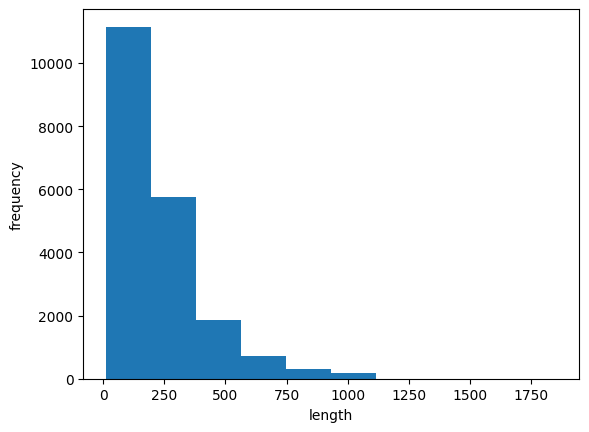

In [33]:
plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequency')
plt.show()

In [34]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [35]:
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [36]:
train_seq.shape, val_seq.shape

((20000, 100), (5000, 100))

In [37]:
train_seq[0]

array([ 10,   4,  20,   9,   2,   2,   2,   5,  45,   6,   2,   2,  33,
         2,   8,   2, 142,   2,   5,   2,  17,  73,  17,   2,   5,   2,
        19,  55,   2,   2,  92,  66, 104,  14,  20,  93,  76,   2, 151,
        33,   4,  58,  12, 188,   2, 151,  12,   2,  69,   2, 142,  73,
         2,   6,   2,   7,   2,   2, 188,   2, 103,  14,  31,  10,  10,
         2,   7,   2,   5,   2,  80,  91,   2,  30,   2,  34,  14,  20,
       151,  50,  26, 131,  49,   2,  84,  46,  50,  37,  80,  79,   6,
         2,  46,   7,  14,  20,  10,  10,   2, 158], dtype=int32)

In [38]:
train_input[0][-10:]

[6, 2, 46, 7, 14, 20, 10, 10, 2, 158]

In [39]:
train_seq[5]
# 앞에 0,0,0,0,0은 길이를 맞춰주느랴고 넣었다? - 0 : Padding, 1: 문장의 시작, 2: 모르는 단어

array([  0,   0,   0,   0,   1,   2, 195,  19,  49,   2,   2, 190,   4,
         2,   2,   2, 183,  10,  10,  13,  82,  79,   4,   2,  36,  71,
         2,   8,   2,  25,  19,  49,   7,   4,   2,   2,   2,   2,   2,
        10,  10,  48,  25,  40,   2,  11,   2,   2,  40,   2,   2,   5,
         4,   2,   2,  95,  14,   2,  56, 129,   2,  10,  10,  21,   2,
        94,   2,   2,   2,   2,  11, 190,  24,   2,   2,   7,  94,   2,
         2,  10,  10,  87,   2,  34,  49,   2,   7,   2,   2,   2,   2,
         2,   2,   2,  46,  48,  64,  18,   4,   2], dtype=int32)

In [40]:
train_input[5]

[1,
 2,
 195,
 19,
 49,
 2,
 2,
 190,
 4,
 2,
 2,
 2,
 183,
 10,
 10,
 13,
 82,
 79,
 4,
 2,
 36,
 71,
 2,
 8,
 2,
 25,
 19,
 49,
 7,
 4,
 2,
 2,
 2,
 2,
 2,
 10,
 10,
 48,
 25,
 40,
 2,
 11,
 2,
 2,
 40,
 2,
 2,
 5,
 4,
 2,
 2,
 95,
 14,
 2,
 56,
 129,
 2,
 10,
 10,
 21,
 2,
 94,
 2,
 2,
 2,
 2,
 11,
 190,
 24,
 2,
 2,
 7,
 94,
 2,
 2,
 10,
 10,
 87,
 2,
 34,
 49,
 2,
 7,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 46,
 48,
 64,
 18,
 4,
 2]

In [41]:
train_input[5][-10:]

[2, 2, 2, 2, 46, 48, 64, 18, 4, 2]

In [51]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Input

model = keras.Sequential()

model.add(Input(shape=(100,200)))
model.add(keras.layers.SimpleRNN(8))
# model.add(keras.layers.SimpleRNN(8, input_shape=(100,500)))
model.add(keras.layers.Dense(1,activation='sigmoid'))

In [43]:
train_seq.shape

(20000, 100)

In [44]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 8)              │         4,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,081 (15.94 KB)

 Trainable params: 4,081 (15.94 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
train_seq.shape

(20000, 100)

In [53]:
train_oh = keras.utils.to_categorical(train_seq)  # OneHotEncoding 작업

train_oh.shape

(20000, 100, 200)

In [54]:
val_oh = keras.utils.to_categorical(val_seq)

val_oh.shape

(5000, 100, 200)

In [55]:
train_oh[0]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(100, 200))

In [56]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best_simplernn_model.keras', save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(train_oh, train_target, epochs=100, batch_size=128, validation_data=(val_oh, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4978 - loss: 0.7114 - val_accuracy: 0.4998 - val_loss: 0.7068
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5005 - loss: 0.7055 - val_accuracy: 0.4988 - val_loss: 0.7032
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5011 - loss: 0.7019 - val_accuracy: 0.4996 - val_loss: 0.7010
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5046 - loss: 0.6995 - val_accuracy: 0.5008 - val_loss: 0.6994
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5056 - loss: 0.6977 - val_accuracy: 0.4976 - val_loss: 0.6983
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5094 - loss: 0.6964 - val_accuracy: 0.4998 - val_loss: 0.6974
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5106 - loss: 0.6953 - val_accuracy: 0.5002 - val_loss: 0.6967
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5120 - loss: 0.6943 - val_acc

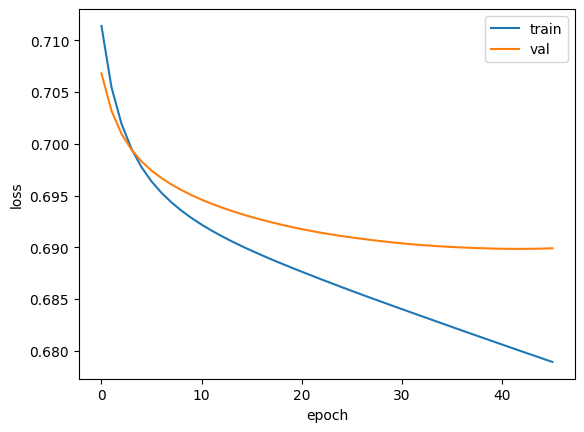

In [57]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','val'])
plt.show()

(20000, 100, 200)
-> 
리뷰 = 2만개 = 샘플 수
1리뷰의 총 단어 수 = 100개
1 단어가 원-핫 인코딩 된 전체 리스트 길이 = 200

그래서 

In [58]:
from tensorflow.keras.datasets import imdb
(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=200)

In [59]:
train_input.shape, train_target.shape

((25000,), (25000,))

In [60]:
from sklearn.model_selection import train_test_split

train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42
)

In [61]:
train_input.shape, train_target.shape, val_input.shape, val_target.shape

((20000,), (20000,), (5000,), (5000,))

In [62]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [63]:
train_seq.shape, val_seq.shape

((20000, 100), (5000, 100))

In [64]:
from tensorflow import keras

model2 = keras.Sequential()
model2.add(keras.layers.Input(shape=(100,)))
model2.add(keras.layers.Embedding(200, 16))
model2.add(keras.layers.SimpleRNN(8))
model2.add(keras.layers.Dense(1, activation='sigmoid'))

model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 16)        │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,409 (13.32 KB)

 Trainable params: 3,409 (13.32 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model2.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best_simplernn_model.keras', save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history = model2.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5643 - loss: 0.6807 - val_accuracy: 0.6374 - val_loss: 0.6584
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6526 - loss: 0.6493 - val_accuracy: 0.6498 - val_loss: 0.6460
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6780 - loss: 0.6345 - val_accuracy: 0.6810 - val_loss: 0.6317
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6919 - loss: 0.6237 - val_accuracy: 0.6858 - val_loss: 0.6238
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7000 - loss: 0.6136 - val_accuracy: 0.6730 - val_loss: 0.6224
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7064 - loss: 0.6054 - val_accuracy: 0.7008 - val_loss: 0.6038
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7091 - loss: 0.5983 - val_accuracy: 0.7098 - val_loss: 0.5953
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7140 - loss: 0.5913 - val_accu

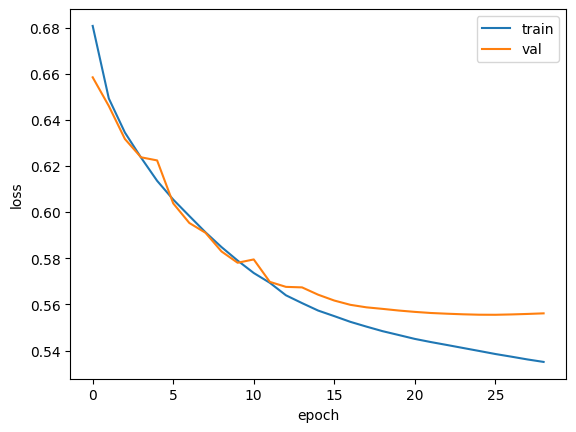

In [66]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','val'])
plt.show()

아다마르 곱
-> 같은 크기를 가진 두 행렬을 원소별로 곱하는 연산